# makemore: part 3

In [74]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [19]:
# MLP revisited  初始情况
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)  
W2 = torch.randn((n_hidden, vocab_size),          generator=g) 
b2 = torch.randn(vocab_size,                      generator=g)  
b2 = torch.randn(vocab_size,                      generator=g)

# # BatchNorm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [68]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

# --- 重新初始化所有参数 ---
g = torch.Generator().manual_seed(2147483647)

# 1. 基础层参数
C = torch.randn((27, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
# 注意：b1 已经被丢弃了，不需要定义 b1

W2 = torch.randn((n_hidden, 27), generator=g) * 0.01
b2 = torch.zeros(27)

# 2. Batch Norm 可训练参数（缩放和平移）
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

# 3. 统一打包进可训练参数列表
parameters = [C, W1, W2, b2, bngain, bnbias] # 🌟 严格检查是不是这6个，不多也不少

# 4. 开启求导开关
for p in parameters:
    p.requires_grad = True

# --- 别忘了还有两个独立于 parameters 之外的历史账本 ---
# 🌟 这两个变量绝对不要放进上面的 parameters 列表里！
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

print(f"成功初始化了 {len(parameters)} 个可训练参数。")

成功初始化了 6 个可训练参数。


tensor(-0.0055) tensor(0.9863)
tensor(0.0051) tensor(3.1220)


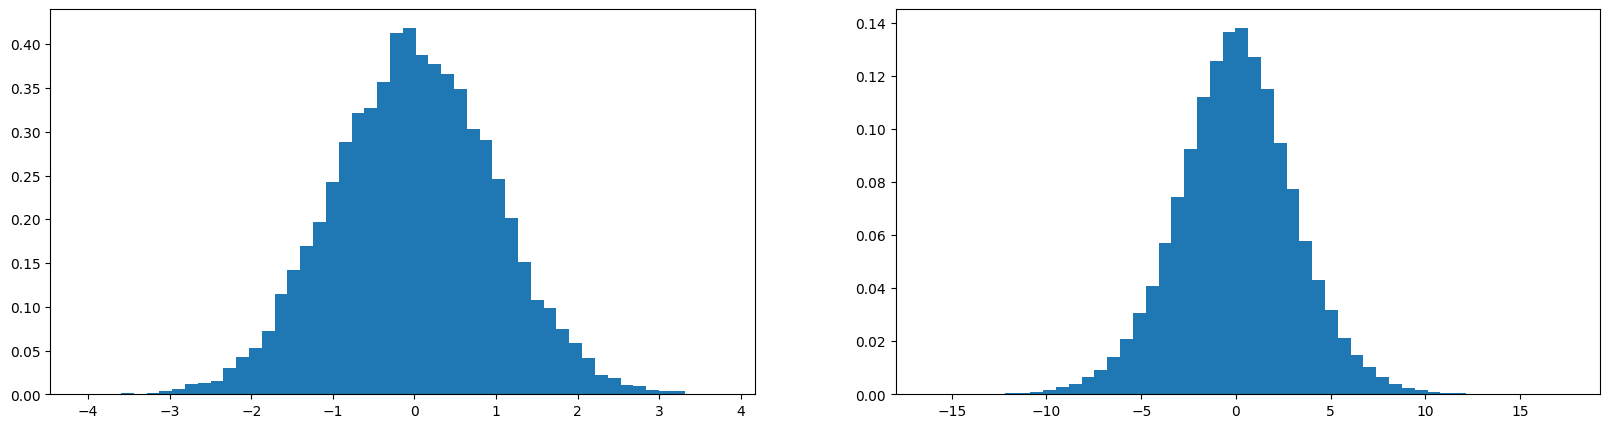

In [48]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);


tensor(0.0016) tensor(0.9937)
tensor(0.0014) tensor(1.0262)


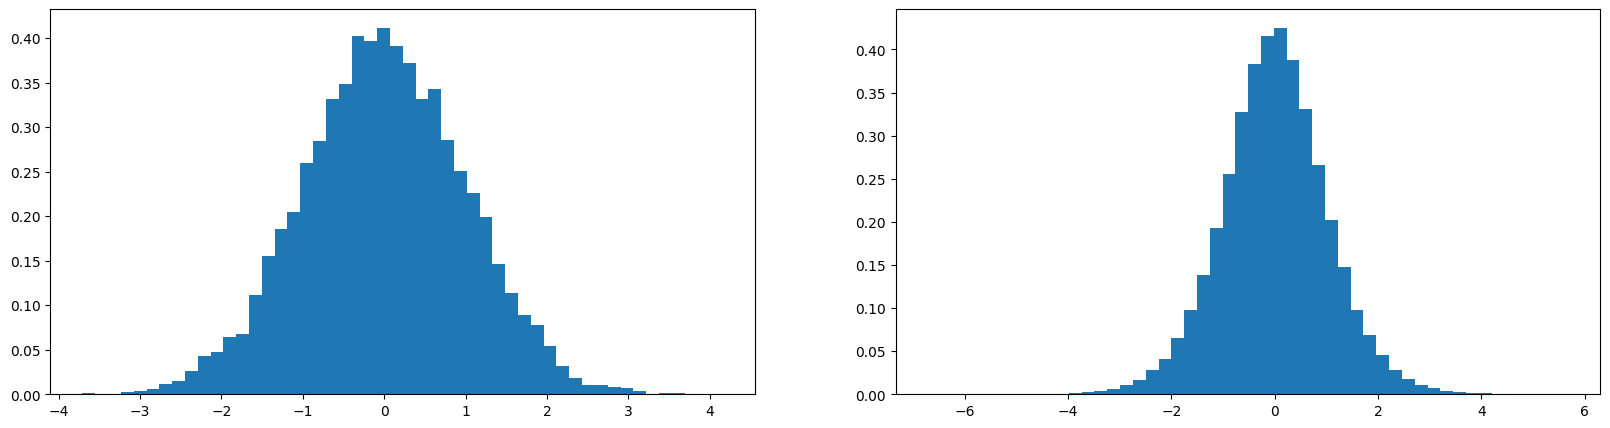

In [49]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);


In [10]:
# same optimization as last time
max_steps = 200000  # 总训练步数
batch_size = 32     
lossi = []          # 记录损失值

for i in range(max_steps):
  
  # minibatch construct  小批量数据构造
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # 字符索引转换为嵌入向量 ，形状: (batch_size, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # 形状变为: (batch_size, block_size * n_embd)
  # Linear layer
  hpreact = embcat @ W1 + b1 # 第一个隐藏层
  # # BatchNorm layer
  # # -------------------------------------------------------------
  # bnmeani = hpreact.mean(0, keepdim=True)
  # bnstdi = hpreact.std(0, keepdim=True)
  # hpreact = embcat @ W1 + b1
  # with torch.no_grad():
  #   bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
  #   bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # 输出预测分数
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 27.8817
  10000/ 200000: 2.9356
  20000/ 200000: 2.5331
  30000/ 200000: 2.9308
  40000/ 200000: 2.1004
  50000/ 200000: 2.4989
  60000/ 200000: 2.4067
  70000/ 200000: 2.1295
  80000/ 200000: 2.3477
  90000/ 200000: 2.3098
 100000/ 200000: 2.0809
 110000/ 200000: 2.3818
 120000/ 200000: 2.0194
 130000/ 200000: 2.4772
 140000/ 200000: 2.2544
 150000/ 200000: 2.1509
 160000/ 200000: 2.0979
 170000/ 200000: 1.8214
 180000/ 200000: 1.9808
 190000/ 200000: 1.8395


In [69]:
# same optimization as last time
max_steps = 200000  # 总训练步数
batch_size = 32     
lossi = []          # 记录损失值

for i in range(max_steps):
  
  # minibatch construct  小批量数据构造
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # 字符索引转换为嵌入向量 ，形状: (batch_size, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # 形状变为: (batch_size, block_size * n_embd)
  # Linear layer
  hpreact = embcat @ W1 # + b1 # 第一个隐藏层
  # # BatchNorm layer
  # # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
    # 强制转换为（0， 1）的正态分布
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # 输出预测分数
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.3195
  10000/ 200000: 2.4145
  20000/ 200000: 2.3325
  30000/ 200000: 1.9968
  40000/ 200000: 2.1420
  50000/ 200000: 1.8543
  60000/ 200000: 2.0658
  70000/ 200000: 2.3749
  80000/ 200000: 1.7567
  90000/ 200000: 2.1471
 100000/ 200000: 1.9758
 110000/ 200000: 2.2732
 120000/ 200000: 2.2282
 130000/ 200000: 2.2719
 140000/ 200000: 2.0277
 150000/ 200000: 2.1609
 160000/ 200000: 2.1316
 170000/ 200000: 2.2845
 180000/ 200000: 1.8789
 190000/ 200000: 2.1965


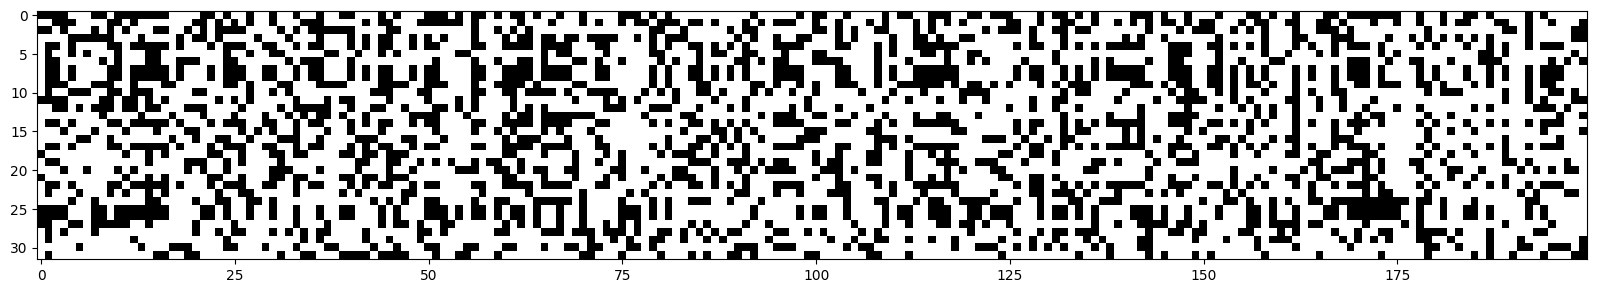

In [32]:
plt.figure(figsize=(20,10))
#        #将激活后的h取绝对值    白色表示死神经元
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

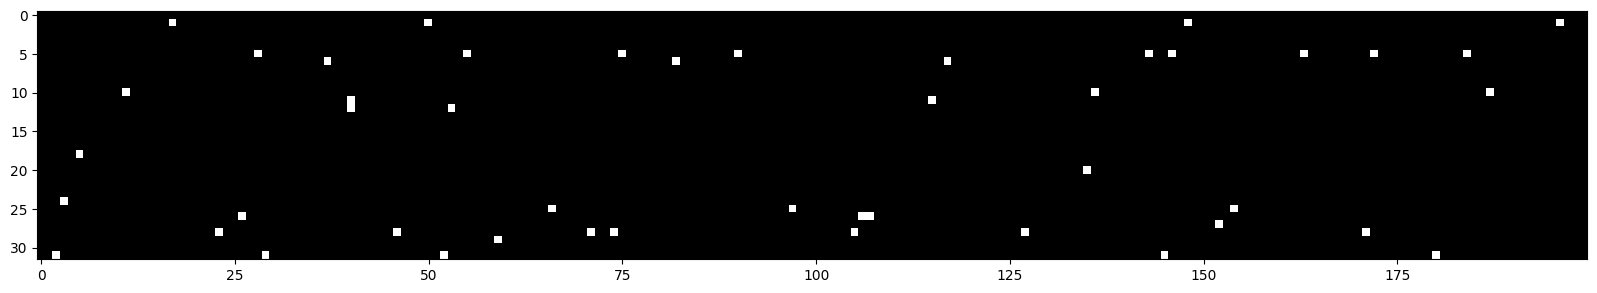

In [58]:
plt.figure(figsize=(20,10))
#        #将激活后的h取绝对值    白色表示死神经元
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

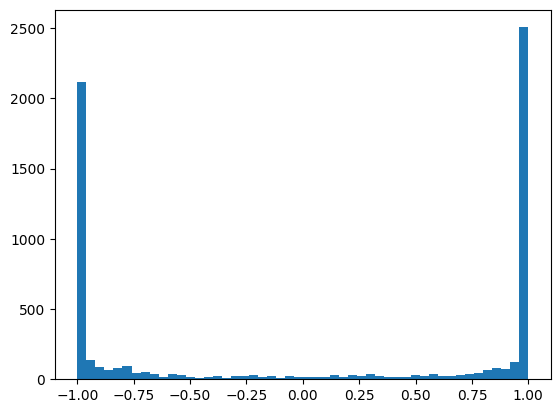

In [26]:
plt.hist(h.view(-1).tolist(), 50);

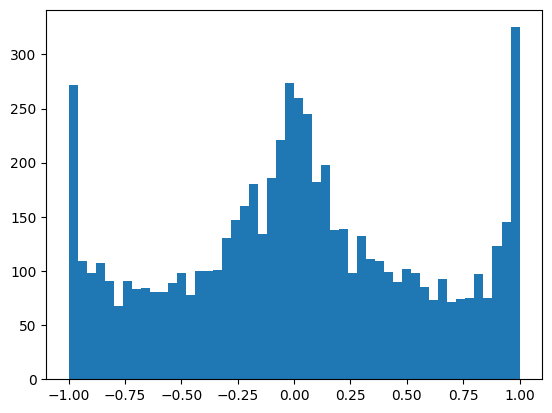

In [37]:
# 新状态
plt.hist(h.view(-1).tolist(), 50);

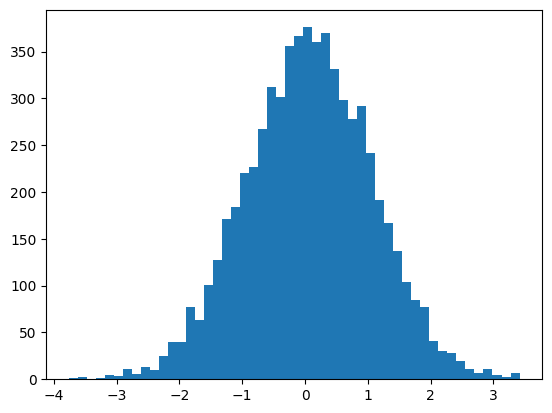

In [42]:
plt.hist(hpreact.view(-1).tolist(), 50);

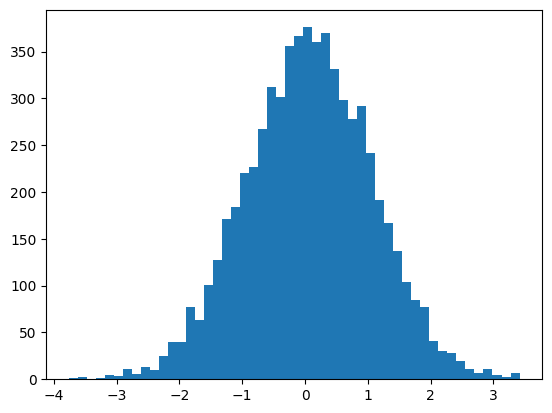

In [43]:
# 新状态
plt.hist(hpreact.view(-1).tolist(), 50);

In [18]:
logits[0]    # 没有对权重，embedding, W1， W2，b1, b2进行合理初始化，

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

In [12]:
# 刚开始的损失值太大了，按照27个符号的概率相等应该为 1/27，转换为负对数为
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [14]:
# 举个例子
#logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits,probs, loss

(tensor([-1.2445,  0.2091,  0.1357,  0.7689]),
 tensor([0.0597, 0.2555, 0.2374, 0.4473]),
 tensor(1.4378))

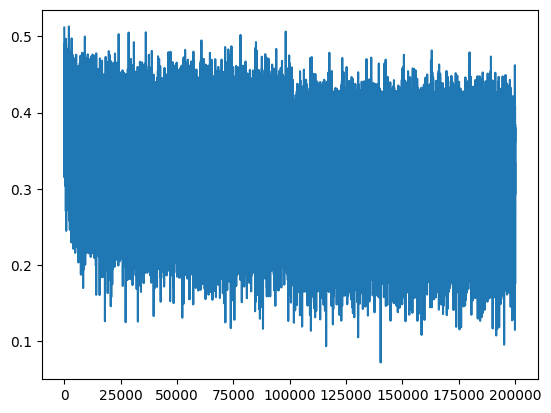

In [45]:
plt.plot(lossi)

In [60]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [61]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(embcat @ W1 + b1) 
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.772512197494507
val 2.800046682357788


## loss log

### original:
train 2.1245384216308594
val   2.168196439743042

### fix softmax confidently wrong:
train 2.07
val   2.13

### fix tanh layer too saturated at init:
train 2.0355966091156006
val   2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer
train 2.0668270587921143
val 2.104844808578491


In [12]:
# SUMMARY + PYTORCHIFYING -----------

In [73]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch
import torch

class Linear:
  
    def __init__(self, fan_in, fan_out, bias=True):
        # Kaiming 初始化（He 初始化）的简化版本，目的是让前向传播时每一层的输出方差大致保持一致，避免梯度消失或爆炸
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
  
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
  
    def parameters(self):
        """返回该层所有可训练参数"""
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    #                 特征维度  防止除以0    用于更新均值和方差的动量参数
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim) # 缩放参数
        self.beta = torch.zeros(dim) # 平移参数
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)  # 全局运行均值
        self.running_var = torch.ones(dim)    # 全局运行方差
  
    def __call__(self, x):
      
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # 这是 BatchNorm 的核心公式：把输入减去均值，再除以标准差 → 得到均值为0，方差为1的归一化数据
        self.out = self.gamma * xhat + self.beta # 加上缩放和平移
      
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
  
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        """没有可训练参数，返回空列表"""
        return []


n_embd = 10 # embedding 维度
n_hidden = 100
g = torch.Generator().manual_seed(2147483647) # 随机数字生成器

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#    Linear(n_embd * block_size, n_hidden), Tanh(),
#    Linear(           n_hidden, n_hidden), Tanh(),
#    Linear(           n_hidden, n_hidden), Tanh(),
#    Linear(           n_hidden, n_hidden), Tanh(),
#    Linear(           n_hidden, n_hidden), Tanh(),
#    Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
    # 如果最后一层输出有 batchnorm,则让 gamma缩小10倍， 使softmax更好拟合
    layers[-1].gamma *= 0.1
    #layers[-1].weight *= 0.1 # 另一种做法，直接缩小权重
    # all other layers: apply gain
    for layer in layers[:-1]: # 除最后一层以外的所有层
        if isinstance(layer, Linear):  # 只对linear层生效
            layer.weight *= 5/3

#      embedding矩阵列表
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # 模型总参数
for p in parameters:
    p.requires_grad = True

47024


In [75]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update_ratio = (p.grad.std() / p.data.std()).log10(), 关于更新步长的监控

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  # 使用随机生成的索引取出样本和标签
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
        # batch当前的字符索引
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # 保存中间激活值的梯度
  for p in parameters:
    p.grad = None
  loss.backward()  # 在这里会自动计算 C、 weight、bias、gamma、bete的梯度
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      
  lossi.append(loss.log10().item()) # 记录损失历史，便于作画
    
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 1000:
  #   break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1043
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2264
  60000/ 200000: 1.7339
  70000/ 200000: 2.1746
  80000/ 200000: 2.1895
  90000/ 200000: 1.8282
 100000/ 200000: 2.3639
 110000/ 200000: 2.2594
 120000/ 200000: 2.0967
 130000/ 200000: 1.8985
 140000/ 200000: 1.8309
 150000/ 200000: 1.9425
 160000/ 200000: 1.8674
 170000/ 200000: 1.8341
 180000/ 200000: 2.2497
 190000/ 200000: 2.0144


layer 2 (      Tanh): mean -0.01, std 0.70, saturated: 16.34%
layer 5 (      Tanh): mean -0.02, std 0.74, saturated: 19.16%
layer 8 (      Tanh): mean -0.00, std 0.77, saturated: 19.06%
layer 11 (      Tanh): mean +0.02, std 0.79, saturated: 20.81%
layer 14 (      Tanh): mean -0.01, std 0.81, saturated: 23.12%


Text(0.5, 1.0, 'activation distribution')

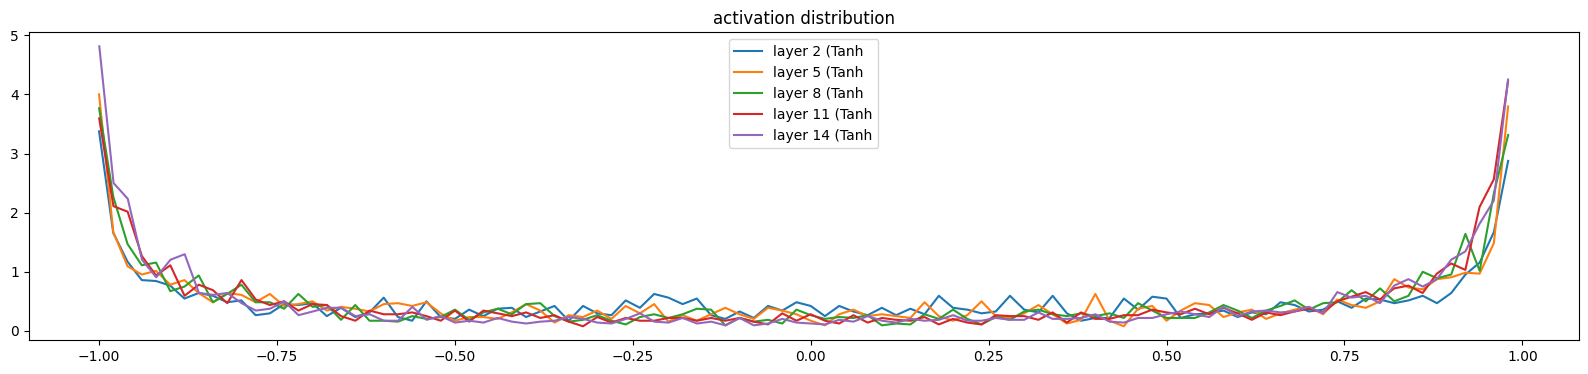

In [76]:
# 前向传播激活值分布
plt.figure(figsize=(20, 4)) # 创建画布
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  # 只对激活层进行可视化
  if isinstance(layer, Tanh):
    t = layer.out # 取出该层前向转播的输出            饱和率，过高梯度消失
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.181741e-03
layer 5 (      Tanh): mean +0.000000, std 3.066077e-03
layer 8 (      Tanh): mean -0.000000, std 3.128345e-03
layer 11 (      Tanh): mean +0.000000, std 3.452782e-03
layer 14 (      Tanh): mean +0.000000, std 3.800394e-03


Text(0.5, 1.0, 'gradient distribution')

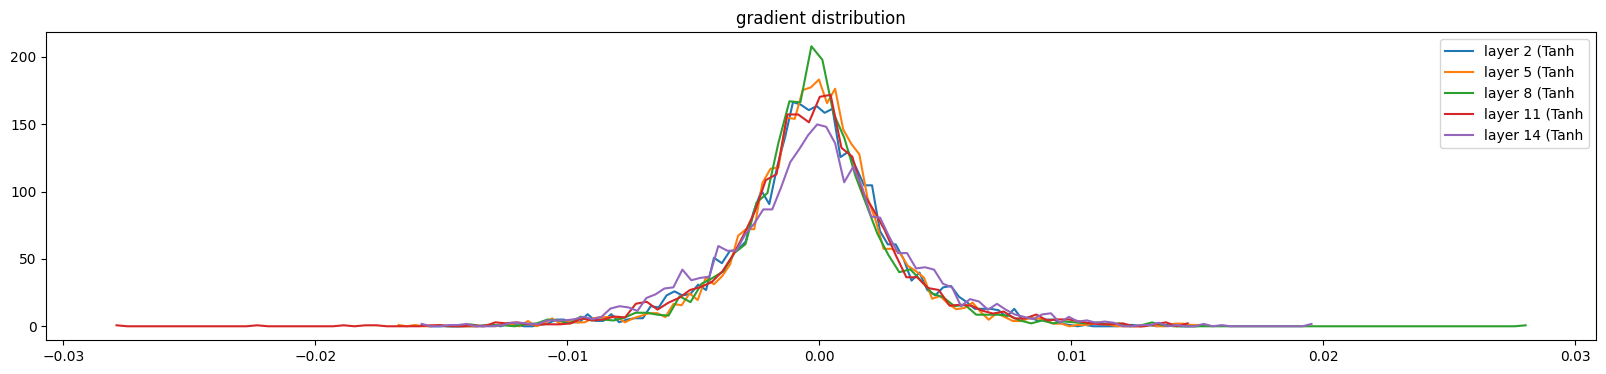

In [77]:
# 前向传播激活值的饱和度
# X轴：梯度大小  Y轴：频率大小
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

# X轴：梯度的数值大小

weight   (27, 10) | mean -0.000000 | std 1.369588e-02 | grad:data ratio 1.194503e-02
weight  (30, 100) | mean +0.000060 | std 6.414552e-03 | grad:data ratio 1.430412e-02
weight (100, 100) | mean +0.000059 | std 4.181695e-03 | grad:data ratio 1.533996e-02
weight (100, 100) | mean -0.000078 | std 4.400899e-03 | grad:data ratio 1.639300e-02
weight (100, 100) | mean +0.000021 | std 4.556504e-03 | grad:data ratio 1.745905e-02
weight (100, 100) | mean -0.000019 | std 4.728334e-03 | grad:data ratio 1.876663e-02
weight  (100, 27) | mean +0.000047 | std 8.237640e-03 | grad:data ratio 2.209811e-02


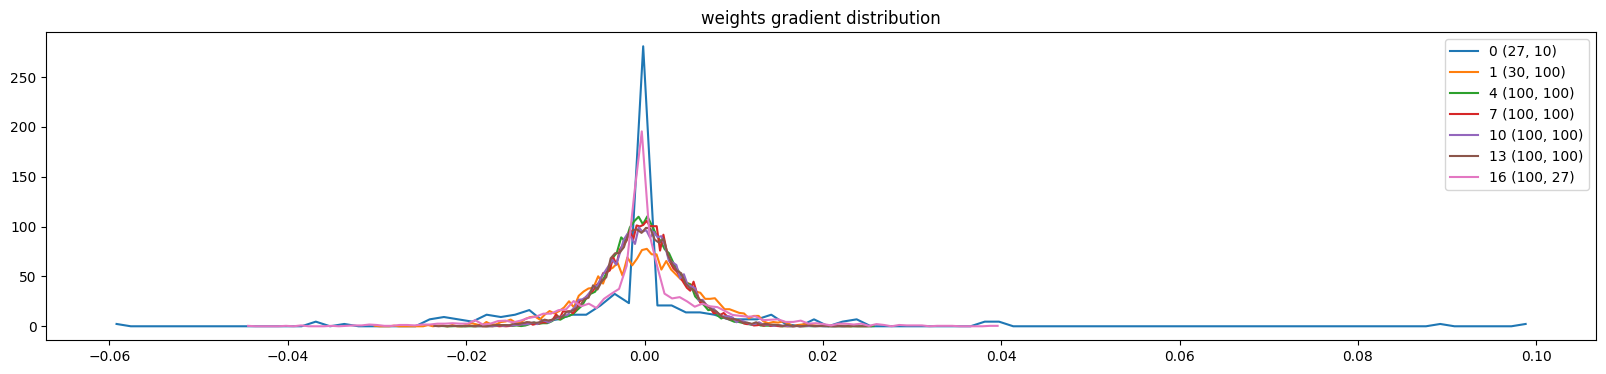

In [78]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

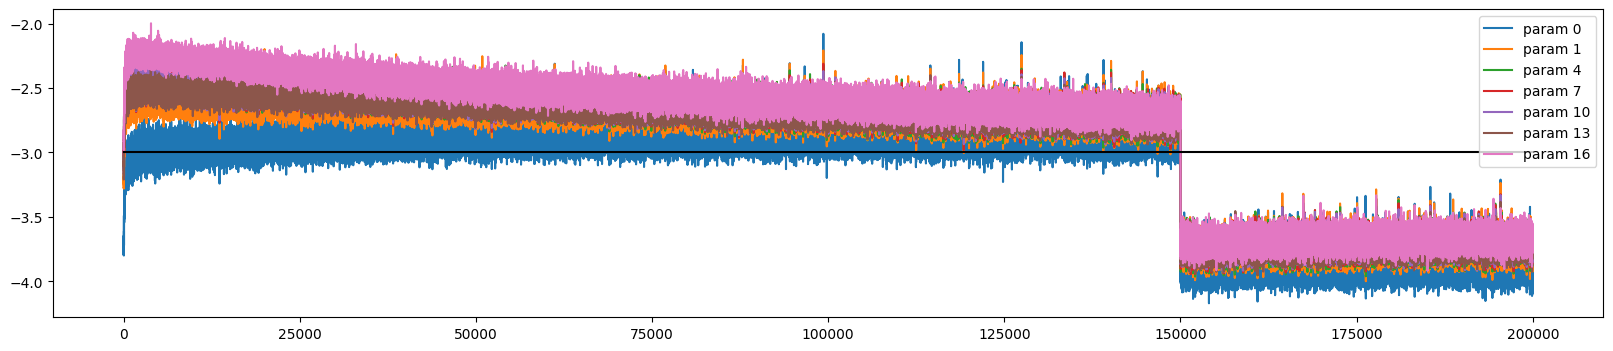

In [79]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [80]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.003941059112549
val 2.080615758895874


In [83]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

montaymyah.
see.
madhayla.
reisra.
ejdra.
grazered.
elin.
shivaelle.
elisson.
arleigh.
malaia.
noshubergiagriel.
kin.
renleigh.
terianuel.
ged.
ryylani.
elsy.
majahsanyah.
halisa.


In [21]:
# DONE; BONUS content below, not covered in video

In [22]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # 把第一个数据替换成滑块控制的值
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

In [23]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [24]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953052997589111
